In [1]:
# This is the most up to date code from langchain. Others we have been using, like the ones from the book of Alammar,
# still work but are a bit out of date

https://python.langchain.com/docs/tutorials/rag/

### Load documents

In [1]:
from langchain_community.document_loaders import PyMuPDFLoader 
from pathlib import Path
#from langchain_community.document_loaders.parsers import TesseractBlobParser #In case there are images with text

from langchain_text_splitters import RecursiveCharacterTextSplitter 
#I decided not to use RecursiveCharacterTextSplitter. Maybe it is useful for regular documents, but not for boardgames rulebooks
#Character was also not great since the first splitting hierarchy is /n/n. Decided to keep it with recursive

import os
from dotenv import load_dotenv
load_dotenv()  # Loads from .env

from langchain.chat_models import init_chat_model
COHERE_API_KEY=os.getenv("COHERE_TOKEN")
os.environ["COHERE_API_KEY"]=COHERE_API_KEY 

from langchain_cohere import CohereEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore

In [2]:
#Change prints for logging

In [3]:
embeddings = CohereEmbeddings(model="embed-v4.0")
vector_store = InMemoryVectorStore(embeddings)

In [4]:
try:
    # Works in regular Python scripts
    base_dir = Path(__file__).resolve().parent.parent
except NameError:
    # Fallback for Jupyter notebooks and interactive shells
    base_dir = Path().resolve().parent

path_rules_pdf = base_dir / "data" / 'raw-rulebooks' 

print(path_rules_pdf)

C:\Users\Carlos Ivan\Documents\Projects\boardgames-assistant\data\raw-rulebooks


In [5]:
pdf_files = [f.name for f in path_rules_pdf.glob("*.pdf")]
print(pdf_files)

['Paleo_FAQ_11-12-20_ENG.pdf', 'Paleo_Rulebook_EN_compressed.pdf', 'Power-Grid-Recharged-Rules.pdf']


In [6]:
for a_pdf in pdf_files:

    a_loader = PyMuPDFLoader(path_rules_pdf / a_pdf,
                        #mode="single", # Comment this to have different documents per page #The splitter we use appends pages, and it needs to be done without single
                        #extract_tables="markdown", #adds tables at the end of the page
                        #images_inner_format="html-img",  #Did not see huge improvements when using it 
                        #images_parser=TesseractBlobParser(),
                        )
    
    a_doc = a_loader.load()
    # It took less than 1 second without tables
    # extract_tables takes significatnly longer than without it (20 seconds)
    # with tables and images using tesseract (good quality) it took 29 seconds

    print(f'Number of characters of {a_pdf}: {sum([len(a.page_content) for a in a_doc])}') #Total characters

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1500,  # chunk size (characters)
        chunk_overlap=300,  # chunk overlap (characters)
        add_start_index=True,  # track index in original document
    )

    all_splits = text_splitter.split_documents(a_doc)
    print(f"Split blog post into {len(all_splits)} sub-documents.")

    # Append to each split name of pdf (in case metadata is not included in )
    for a_split in all_splits:
        # added to the chunks both the name of the rule book and the page from the chunk comes from (useful to ask in which page to find something) 
        a_split.page_content = 'Game: ' + a_pdf.split('.')[0] + f', page {a_split.metadata["page"]}' + '. Content: ' + a_split.page_content
        a_split.metadata['game']= a_pdf.split('.')[0] 

    # Add embeddings of the splits into the vector store
    _ = vector_store.add_documents(documents=all_splits)
    print(f'Size of vector store until now: {len(vector_store.store.items())}')

Number of characters of Paleo_FAQ_11-12-20_ENG.pdf: 6817
Split blog post into 7 sub-documents.
Size of vector store until now: 7
Number of characters of Paleo_Rulebook_EN_compressed.pdf: 28907
Split blog post into 27 sub-documents.
Size of vector store until now: 34
Number of characters of Power-Grid-Recharged-Rules.pdf: 42207
Split blog post into 37 sub-documents.
Size of vector store until now: 71


# Search and generation

In [7]:
# For this to work the cohere api key needs to be as env variable with the name COHERE_API_KEY
model = init_chat_model("command-a-03-2025", model_provider="cohere")

In [8]:

from langchain.prompts import ChatPromptTemplate

prompt_ours = ChatPromptTemplate.from_messages([
    ("system", "You are an assistant for question-answering tasks. "
               "Use the following pieces of retrieved context to answer the question. "
               "If you don't know the answer, just say that you don't know, don't try to make up an answer."
               "Use between three to 5 sentences maximum and keep the answer concise."),
    ("human", "Question: {question}\nContext: {context}\nAnswer:")
])


In [10]:
prompt_ours.invoke({"question": 'Who is the Taats Foo', "context": 'The Toot is the Foo of the Taat'})

ChatPromptValue(messages=[SystemMessage(content="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know, don't try to make up an answer.Use between three to 5 sentences maximum and keep the answer concise.", additional_kwargs={}, response_metadata={}), HumanMessage(content='Question: Who is the Taats Foo\nContext: The Toot is the Foo of the Taat\nAnswer:', additional_kwargs={}, response_metadata={})])

We'll use **LangGraph** to tie together the retrieval and generation steps into a single application. This will bring a number of benefits:

* We can define our application logic once and automatically support multiple invocation modes, including streaming, async, and batched calls.
* We get streamlined deployments via LangGraph Platform.
* LangSmith will automatically trace the steps of our application together.
* We can easily add key features to our application, including persistence and human-in-the-loop approval, with minimal code changes.

To use LangGraph, we need to define three things:

* The state of our application;
* The nodes of our application (i.e., application steps);
* The "control flow" of our application (e.g., the ordering of the steps).

In [11]:
# STATE

#The state of our application controls what data is input to the application, transferred between steps, and output by the application.
#  It is typically a TypedDict, but can also be a Pydantic BaseModel.

#For a simple RAG application, we can just keep track of the input question, retrieved context, and generated answer:

from langchain_core.documents import Document
from typing_extensions import List, TypedDict


class State(TypedDict):
    question: str
    context: List[Document]
    answer: str

In [12]:
# NODES
# Let's start with a simple sequence of two steps: retrieval and generation.


def retrieve(state: State):
    retrieved_docs = vector_store.similarity_search(state["question"])
    return {"context": retrieved_docs}


def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt_ours.invoke({"question": state["question"], "context": docs_content})
    response = model.invoke(messages)
    return {"answer": response.content}

In [13]:
# CONTROL FLOW

In [14]:
# Finally, we compile our application into a single graph object. In this case, we are just connecting the retrieval and generation 
# steps into a single sequence.

from langgraph.graph import START, StateGraph

graph_builder = StateGraph(State).add_sequence([retrieve, generate]) #equivalent to adding edges
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

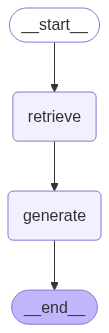

In [15]:
#LangGraph also comes with built-in utilities for visualizing the control flow of your application:

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

# Testing rag

In [16]:
# Add the extensions of powergrid

In [17]:
for message, metadata in graph.stream(
    {"question": "What is the number of playable regions in powergrid?"}, stream_mode="messages"
):
    print(message.content, end="")

The number of playable regions in Power Grid depends on the number of players and the chosen map. For the Germany map, there are 6 areas, each with 7 cities. Players choose a contiguous playing zone of connected areas, which can vary based on the number of players. For example, in a 2-player game, a smaller zone might be selected, while a larger zone is used for more players. The exact number of regions in the playing zone is not fixed but is determined by the players' choice during setup.

In [20]:
result = graph.invoke({"question": "In which page can I read what happens after step 3 starts?"})


In [21]:
print(f"Answer: {result['answer']}")


Answer: You can read what happens after Step 3 starts on **page 11** of the Power-Grid-Recharged-Rules. This page details the changes and rules specific to Step 3, including adjustments to the power plant market, city network rules, building costs, and resource resupply.


In [27]:
result

{'question': 'Up to how many people can play powergrid?',
 'context': [Document(id='233508cc-6aad-4bc2-ac12-170ec6189836', metadata={'producer': 'Adobe PDF Library 8.0', 'creator': 'Adobe InDesign CS3 (5.0.4)', 'creationdate': '2018-07-26T15:22:09+02:00', 'source': 'C:\\Users\\Carlos Ivan\\Documents\\Projects\\boardgames-assistant\\data\\raw-rulebooks\\Power-Grid-Recharged-Rules.pdf', 'file_path': 'C:\\Users\\Carlos Ivan\\Documents\\Projects\\boardgames-assistant\\data\\raw-rulebooks\\Power-Grid-Recharged-Rules.pdf', 'total_pages': 12, 'format': 'PDF 1.4', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2020-05-08T13:58:23-04:00', 'trapped': '', 'modDate': "D:20200508135823-04'00'", 'creationDate': "D:20180726152209+02'00'", 'page': 7, 'start_index': 0}, page_content='Power-Grid-Recharged-Rules: Number of players\n2\n3–4\n5\n6\nConnected cities\n18\n17\n15\n14\n!\nExample: For 3–4 players, the game ends after \na player connects 17 cities.\nStep 3\nWhen you draw t

64

In [18]:
prompt_template = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You talk like a pirate. Answer all questions to the best of your ability in {language}.",
        ),
        MessagesPlaceholder(variable_name="messages"), #the variable name is important. MessagesState has that field
    ]
)
#Note that we have added a new language input to the prompt. Our application now has two parameters-- the input messages 
# and language. We no longer can use the MessagesState class since it does not contain the field language. Hence,
# we create a custom message state class


from typing import Sequence

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from typing_extensions import Annotated, TypedDict


class StateWithLanguage(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    language: str

In [ ]:




# Trimmer to manage memory. In the future, we could change that for a summary of all the history
trimmer = trim_messages(
    max_tokens=5000, #maximum context length of command a is 254k tokens
    strategy="last",
    token_counter=model,
    include_system=True,
    allow_partial=False,
    start_on="human",
)    


# Define the function that calls the model
def call_model(state: StateWithLanguage): # Without language var it was state: MessagesState
    trimmed_messages = trimmer.invoke(state["messages"]) #Avoids overflowing history
    prompt = prompt_template.invoke(
        {"messages": trimmed_messages, "language": state["language"]}
    )
    response = model.invoke(prompt) # Without the prompt template it was model.invoke(state["messages"])
    return {"messages": [response]} #Are the [] needed?



# Define a new graph
workflow = StateGraph(state_schema=StateWithLanguage) # Without language var it was state_schema=MessagesState

# Define the (single) node in the graph
workflow.add_edge(START, "model")
workflow.add_node("model", call_model)

# Add memory
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)